In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import scipy 

import matplotlib as mpl
import matplotlib.pyplot as plt

import numpy as np 
import matplotlib.pyplot as plt 
import scipy.stats as stats
from iminuit import Minuit
import pandas as pd
from scipy.optimize import brentq
from scipy.interpolate import interp1d

# ---- Paper/LaTeX-ish defaults (no TeX install needed) ----
mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 11,

    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,

    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,

    "legend.frameon": False,
})


def autoscale_fonts(fig, base=10, ref_width=6.4):
    """
    Scale fonts relative to figure width.
    ref_width=6.4 in is Matplotlib's default figure width.
    """
    scale = fig.get_figwidth() / ref_width
    fs = base * scale

    for ax in fig.axes:
        ax.title.set_fontsize(fs * 1.1)
        ax.xaxis.label.set_fontsize(fs)
        ax.yaxis.label.set_fontsize(fs)
        ax.tick_params(labelsize=fs * 0.9)

        leg = ax.get_legend()
        if leg is not None:
            for t in leg.get_texts():
                t.set_fontsize(fs * 0.9)

    if fig._suptitle is not None:
        fig._suptitle.set_fontsize(fs * 1.2)

    return fs

def prettify(a):
    a.minorticks_on()
    a.grid(True, which="major", linewidth=0.6, alpha=0.35)
    a.grid(True, which="minor", linewidth=0.4, alpha=0.20)
    a.tick_params(which="both", top=False, right=False)
    
# plt.gca().set_aspect('equal', adjustable='box')
# autoscale_fonts(fig, base=10)
# for i in ax.ravel(): 
#     prettify(i)
#     i.legend()
#     i.set_xlabel(r"$\Theta_{lab}$[Degree]")
#     i.set_ylabel("Counts")
#     i.set_xbound(-15, 15)

In [25]:
components = [
    # name, mean (MeV), sigma (MeV), weight
    ("G1", 3.2, 0.55, 0.030),
    ("G2", 4.1, 0.55, 0.040),
    ("G3", 5.0, 0.55, 0.055),
    ("G4", 5.9, 0.55, 0.070),
    ("G5", 6.8, 0.55, 0.090),
    ("G6", 7.7, 0.55, 0.115),
    ("G7", 8.6, 0.55, 0.135),
    ("G8", 9.4, 0.55, 0.150),
    ("G9", 10.1, 0.55, 0.140),
    ("G10", 10.7, 0.55, 0.110),
    ("G11", 11.3, 0.55, 0.050),
    ("G12", 12.2, 0.55, 0.030),
]

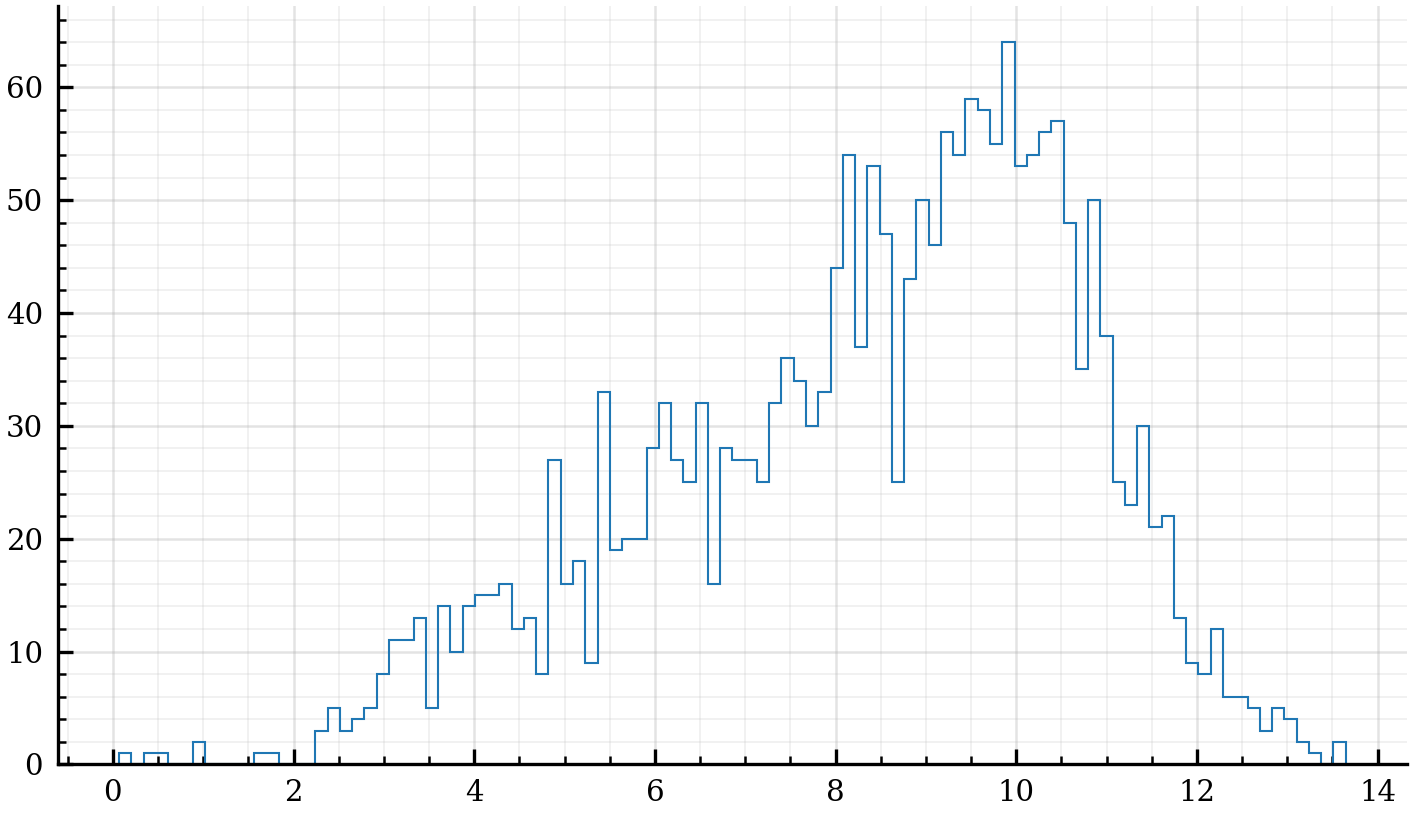

In [24]:
data = np.loadtxt("S2223Test.csv", dtype = str, delimiter=",", skiprows=1, usecols=0).astype(float)
bins = 100
fig, ax = plt.subplots(1, figsize = (5, 3))
plt.hist(data, bins = bins, histtype="step", linewidth=0.5, label=r"$\theta$")

prettify(ax)
autoscale_fonts(fig, base=10)
plt.tight_layout()

In [ ]:
components = [
    # name, mean (MeV), sigma (MeV), weight
    ("G1", 3.2, 0.55, 0.030),
    ("G2", 4.1, 0.55, 0.040),
    ("G3", 5.0, 0.55, 0.055),
    ("G4", 5.9, 0.55, 0.070),
    ("G5", 6.8, 0.55, 0.090),
    ("G6", 7.7, 0.55, 0.115),
    ("G7", 8.6, 0.55, 0.135),
    ("G8", 9.4, 0.55, 0.150),
    ("G9", 10.1, 0.55, 0.140),
    ("G10", 10.7, 0.55, 0.110),
    ("G11", 11.3, 0.55, 0.050),
    ("G12", 12.2, 0.55, 0.030),
]

mean = []
width = []
f = []
for i in range(len(components)):
    mean.append(components[i][1])
    width.append(components[i][2])
    f.append(components[i][-1])
    
bg_weight = 0.025

1.0150000000000001

In [ ]:
def pdf(E, mu, sigma, f):
    return f * stats.norm(E, loc = mu, sigma = sigma)

# compute the likelihood for each pdf
def l(E, mu, sigma, f):
    return pdf(data, mu, sigma, f)



Converged at iter 674, ΔlogL=9.641e-11

Component contributions (yields and fractions):
  G0:  N =    62.84   fraction =  0.0297
  G1:  N =    96.15   fraction =  0.0454
  G2:  N =    82.14   fraction =  0.0388
  G3:  N =   198.71   fraction =  0.0938
  G4:  N =   134.43   fraction =  0.0634
  G5:  N =   250.09   fraction =  0.1180
  G6:  N =   278.86   fraction =  0.1316
  G7:  N =   262.43   fraction =  0.1238
  G8:  N =   367.44   fraction =  0.1734
  G9:  N =   163.82   fraction =  0.0773
 G10:  N =   125.28   fraction =  0.0591
 G11:  N =    55.79   fraction =  0.0263
 BKG:  N =    41.01   fraction =  0.0194


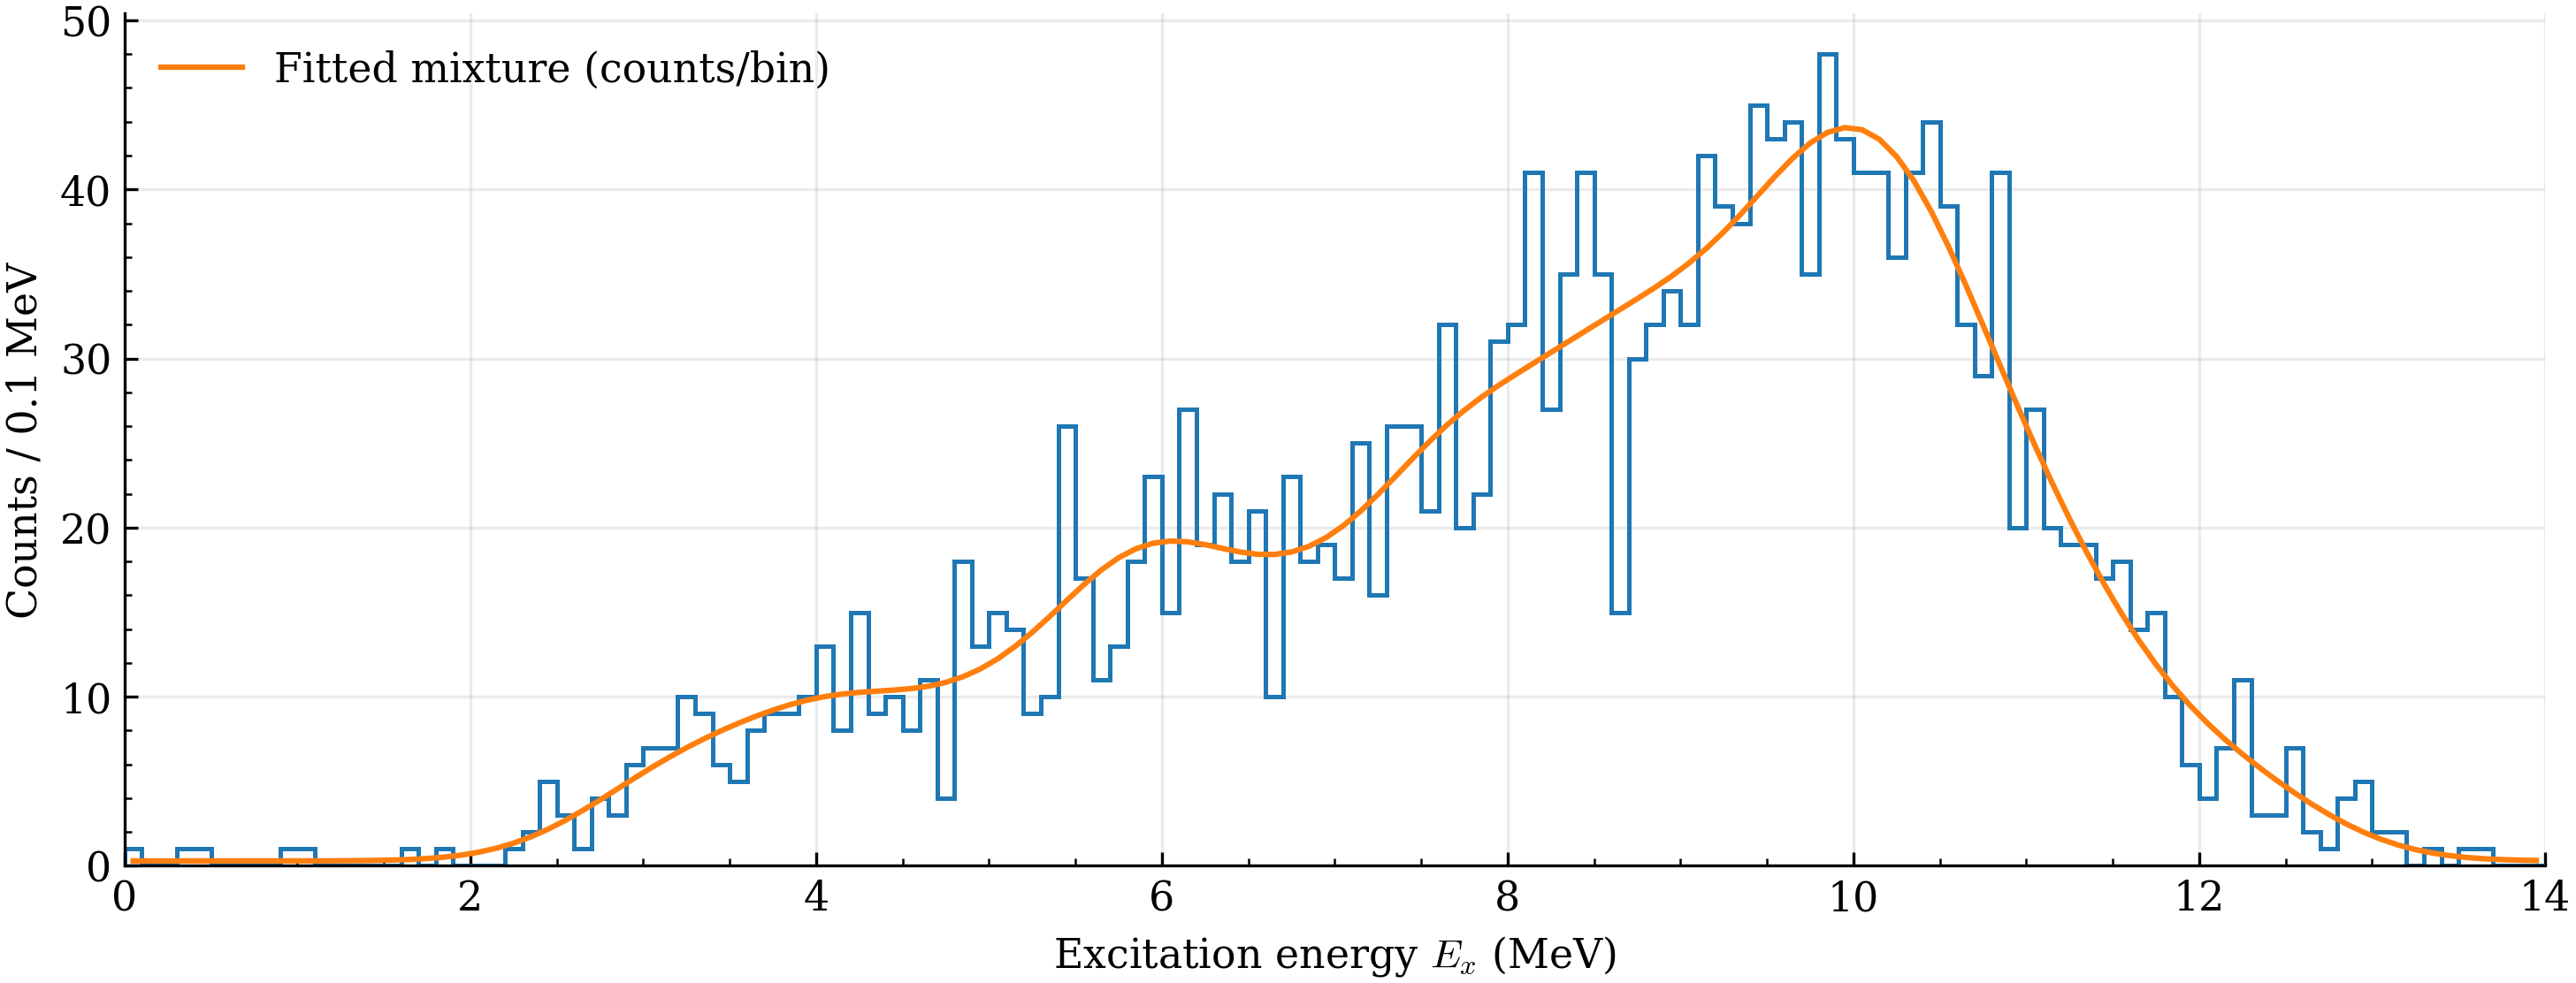

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf

# ---------- PDFs (normalized on a finite fit window) ----------
def norm_cdf(x):
    return 0.5 * (1.0 + erf(x / np.sqrt(2.0)))

def truncated_gauss_pdf(E, mu, sigma, emin, emax):
    """
    Gaussian pdf normalized over [emin, emax].
    This makes fitted yields correspond to expected counts in that window.
    """
    E = np.asarray(E, dtype=float)
    z = (E - mu) / sigma
    pdf = np.exp(-0.5 * z * z) / (np.sqrt(2.0 * np.pi) * sigma)
    Z = norm_cdf((emax - mu) / sigma) - norm_cdf((emin - mu) / sigma)
    return pdf / Z

def uniform_pdf(E, emin, emax):
    E = np.asarray(E, dtype=float)
    return np.full_like(E, 1.0 / (emax - emin), dtype=float)

# ---------- EM fit for weights/yields ----------
def fit_fixed_sigma_mixture_em(Edata, mu_list, sigma=0.55, emin=None, emax=None,
                               include_background=True, max_iter=5000, tol=1e-10, verbose=True):
    """
    Fit mixture weights for fixed Gaussian components (means fixed, sigma fixed).
    Returns yields and weights for each component (+ background if enabled).
    """
    E = np.asarray(Edata, dtype=float)
    if emin is None: emin = float(np.min(E))
    if emax is None: emax = float(np.max(E))
    if not (emin < emax):
        raise ValueError("emin must be < emax")

    mu = np.asarray(mu_list, dtype=float)
    K = len(mu)
    Nobs = len(E)

    # Precompute component PDFs at each event
    G = np.vstack([truncated_gauss_pdf(E, mu[i], sigma, emin, emax) for i in range(K)])  # shape (K, Nobs)

    if include_background:
        B = uniform_pdf(E, emin, emax)[None, :]  # shape (1, Nobs)
        P = np.vstack([G, B])                    # shape (K+1, Nobs)
        names = [f"G{i}" for i in range(K)] + ["BKG"]
    else:
        P = G
        names = [f"G{i}" for i in range(K)]

    M = P.shape[0]  # number of mixture components

    # Initialize weights uniformly
    w = np.full(M, 1.0 / M, dtype=float)

    # EM iterations
    ll_prev = -np.inf
    for it in range(max_iter):
        # responsibilities r_{m,j} = w_m * p_m(E_j) / sum_k w_k * p_k(E_j)
        numer = w[:, None] * P
        denom = np.sum(numer, axis=0)
        # numerical guard (shouldn't happen unless PDFs underflow badly)
        denom = np.maximum(denom, 1e-300)
        R = numer / denom

        # M-step: update weights
        w_new = np.mean(R, axis=1)

        # compute log-likelihood (non-extended; yields = weights * Nobs)
        ll = np.sum(np.log(denom))

        # convergence
        if np.abs(ll - ll_prev) < tol:
            w = w_new
            if verbose:
                print(f"Converged at iter {it}, ΔlogL={ll-ll_prev:.3e}")
            break

        w = w_new
        ll_prev = ll

    # Convert weights -> yields in the fit window
    yields = w * Nobs

    return {
        "weights": w,
        "yields": yields,
        "names": names,
        "emin": emin,
        "emax": emax,
        "sigma": sigma,
        "mu_list": mu_list
    }

# ---------- Plot helper ----------
def plot_fit(Edata, mu_list, fit_result, bins=140):
    E = np.asarray(Edata, dtype=float)
    emin, emax = fit_result["emin"], fit_result["emax"]
    sigma = fit_result["sigma"]
    weights = fit_result["weights"]
    yields = fit_result["yields"]
    names = fit_result["names"]

    # histogram
    fig, ax = plt.subplots(figsize=(10, 4))
    counts, edges, _ = ax.hist(E, bins=np.linspace(emin, emax, bins+1), histtype="step", linewidth=1.2)
    centers = 0.5 * (edges[:-1] + edges[1:])
    binw = edges[1] - edges[0]

    # model curve in counts/bin
    model = np.zeros_like(centers, dtype=float)
    K = len(mu_list)
    for i in range(K):
        gi = truncated_gauss_pdf(centers, mu_list[i], sigma, emin, emax)
        model += yields[i] * gi * binw
    # background if present
    if len(names) == K + 1 and names[-1] == "BKG":
        b = uniform_pdf(centers, emin, emax)
        model += yields[-1] * b * binw

    ax.plot(centers, model, linewidth=1.5, label="Fitted mixture (counts/bin)")
    ax.set_xlabel("Excitation energy $E_x$ (MeV)")
    ax.set_ylabel(f"Counts / {binw:.3g} MeV")
    ax.set_xlim(emin, emax)
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

# ------------------ Example usage ------------------
if __name__ == "__main__":
    # Replace this with your actual Ex array
    # Example: Edata = np.loadtxt("your_ex_values.txt")
    # If using my earlier mock CSV:
    # import pandas as pd
    # df = pd.read_csv("s2223_mock_excitation_energy_blob.csv")
    # Edata = df["Ex_MeV"].to_numpy()

    # Example centers (replace with your known state energies)
    mu_list = [3.2, 4.1, 5.0, 5.9, 6.8, 7.7, 8.6, 9.4, 10.1, 10.7, 11.3, 12.2]

    # Edata must exist; uncomment one of the loaders above
    # Edata = ...

    # Fit
    result = fit_fixed_sigma_mixture_em(
        data, mu_list, sigma=0.55, emin=0.0, emax=14.0,
        include_background=True, verbose=True
    )

    # Print contributions
    print("\nComponent contributions (yields and fractions):")
    for name, Ni, wi in zip(result["names"], result["yields"], result["weights"]):
        print(f"{name:>4s}:  N = {Ni:8.2f}   fraction = {wi:7.4f}")

    # Plot
    plot_fit(data, mu_list, result, bins=140)


In [ ]:
components = [
    # name, mean (MeV), sigma (MeV), weight
    ("G1", 3.2, 0.55, 0.030),
    ("G2", 4.1, 0.55, 0.040),
    ("G3", 5.0, 0.55, 0.055),
    ("G4", 5.9, 0.55, 0.070),
    ("G5", 6.8, 0.55, 0.090),
    ("G6", 7.7, 0.55, 0.115),
    ("G7", 8.6, 0.55, 0.135),
    ("G8", 9.4, 0.55, 0.150),
    ("G9", 10.1, 0.55, 0.140),
    ("G10", 10.7, 0.55, 0.110),
    ("G11", 11.3, 0.55, 0.050),
    ("G12", 12.2, 0.55, 0.030),
]